In [1]:
!pip install tensorflow==2.16.1
import numpy as np
import pandas as pd


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
import kagglehub

path = kagglehub.dataset_download("harshwardhanfartale/eyes-defy-anemia")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'eyes-defy-anemia' dataset.
Path to dataset files: /kaggle/input/eyes-defy-anemia


In [4]:
import pandas as pd

# Load metadata Excel files, update with correct paths as needed
df_india = pd.read_excel('/content/India.xlsx')
df_italy = pd.read_excel('/content/Italy.xlsx')

# Display basic info to check for missing values and datatypes
print("India metadata overview:")
print(df_india.info())
print(df_india.head())

print("\nItaly metadata overview:")
print(df_italy.info())
print(df_italy.head())

# Inspect for missing Hb values
missing_hb_india = df_india[df_india['Hgb'].isna()]
missing_hb_italy = df_italy[df_italy['Hgb'].isna()]
print("\nMissing Hb entries in India.xlsx:", missing_hb_india)
print("\nMissing Hb entries in Italy.xlsx:", missing_hb_italy)

# Drop or handle rows with missing Hb values (except the special cases, like patient 93 from Italy)
df_india_clean = df_india.dropna(subset=['Hgb'])
df_italy_clean = df_italy.dropna(subset=['Hgb'])

# Optionally: keep track of dropped rows for records
dropped_india = df_india[df_india['Hgb'].isna()]
dropped_italy = df_italy[df_italy['Hgb'].isna() & (df_italy['Number'] != 93)]

# Resulting clean dataframes:
print("\nCleaned India metadata size:", df_india_clean.shape)
print("Cleaned Italy metadata size:", df_italy_clean.shape)

India metadata overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Number  95 non-null     int64  
 1   Hgb     95 non-null     float64
 2   Gender  95 non-null     object 
 3   Age     95 non-null     int64  
 4   Note    0 non-null      float64
dtypes: float64(2), int64(2), object(1)
memory usage: 3.8+ KB
None
   Number   Hgb Gender  Age  Note
0       1  12.2      M   29   NaN
1       2   8.0      F   36   NaN
2       3  10.7      F   30   NaN
3       4   8.3      F   39   NaN
4       5   7.8      F   29   NaN

Italy metadata overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Number      123 non-null    int64  
 1   Hgb         123 non-null    object 
 2   Gender      123 non-null    object 
 3   Age

In [5]:
import os
import pandas as pd

# Use the correct column names
def get_anemia_cutoff(gender, age):
    # Convert values for logic
    if not gender or age is None:
        return 12.0  # fallback threshold
    try:
        age = float(age)
    except:
        return 12.0
    if gender == 'M':
        return 13.0
    if gender == 'F':
        if age < 6:
            return 11.0
        elif 6 <= age <= 12:
            return 11.5
        elif 12 <= age <= 15:
            return 12.0
        else:
            return 12.0
    return 12.0  # fallback, for safety

def create_image_label_df(base_path, metadata_df, country_name):
    data = []
    for _, row in metadata_df.iterrows():
        patient_num = str(row['Number'])
        hgb_raw = row['Hgb']

        # Convert Hgb to float safely
        try:
            hgb = float(hgb_raw)
        except (ValueError, TypeError):
            # Skip or handle rows with invalid Hgb
            continue

        age = row['Age']
        gender = row['Gender']
        cutoff = get_anemia_cutoff(gender, age)
        anemia_label = 1 if hgb < cutoff else 0

        patient_folder = os.path.join(base_path, patient_num)
        if not os.path.exists(patient_folder):
            continue

        for img_file in os.listdir(patient_folder):
            if img_file.endswith(('.jpg', '.png')):
                img_path = os.path.join(patient_folder, img_file)
                data.append({
                    'country': country_name,
                    'patient_number': patient_num,
                    'image_path': img_path,
                    'anemia_label': anemia_label,
                    'Hgb': hgb,
                    'age': age,
                    'gender': gender,
                    'cutoff_used': cutoff
                })
    return pd.DataFrame(data)


# Paths
india_base_path = '/kaggle/input/eyes-defy-anemia/dataset anemia/India'
italy_base_path = '/kaggle/input/eyes-defy-anemia/dataset anemia/Italy'

df_india_images = create_image_label_df(india_base_path, df_india_clean, 'India')
df_italy_images = create_image_label_df(italy_base_path, df_italy_clean, 'Italy')

df_all = pd.concat([df_india_images, df_italy_images], ignore_index=True)
print(df_all.head())
print("\nPopulation-specific anemia distribution:\n", df_all['anemia_label'].value_counts())
df_all.to_csv('eyes_defy_anemia_population_label.csv', index=False)

  country patient_number                                         image_path  \
0   India              1  /kaggle/input/eyes-defy-anemia/dataset anemia/...   
1   India              1  /kaggle/input/eyes-defy-anemia/dataset anemia/...   
2   India              1  /kaggle/input/eyes-defy-anemia/dataset anemia/...   
3   India              1  /kaggle/input/eyes-defy-anemia/dataset anemia/...   
4   India              2  /kaggle/input/eyes-defy-anemia/dataset anemia/...   

   anemia_label   Hgb  age gender  cutoff_used  
0             1  12.2   29      M         13.0  
1             1  12.2   29      M         13.0  
2             1  12.2   29      M         13.0  
3             1  12.2   29      M         13.0  
4             1   8.0   36      F         12.0  

Population-specific anemia distribution:
 anemia_label
0    442
1    358
Name: count, dtype: int64


Removed 55 invalid or corrupted images.
Examples of invalid files: ['/kaggle/input/eyes-defy-anemia/dataset anemia/India/1/20200118_164733_forniceal_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/India/2/20200124_154320_forniceal_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/India/7/20200124_202058_forniceal_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/India/10/20200203_091841_forniceal_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/India/13/20200203_190841_forniceal_palpebral.png']


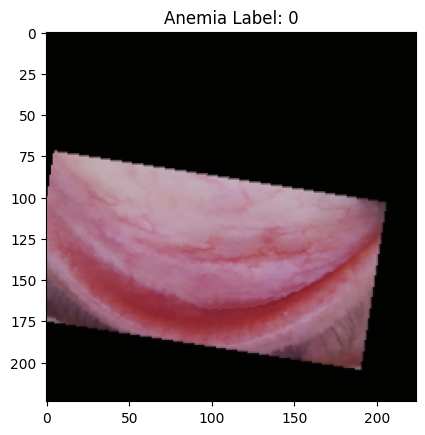

In [6]:
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader


class AnemiaDataset(Dataset):
    def __init__(self, dataframe, image_column='image_path', label_column='anemia_label', transform=None):
        self.df = dataframe
        self.image_column = image_column
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['anemia_label']
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Warning: Skipping unreadable image: {img_path} - {e}")
            image = Image.new('RGB', (224,224), (0,0,0))  # fallback
        if self.transform:
            image = self.transform(image)
        return image, label



# Define transforms: resize, augmentations, normalize
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),      # Rotate ±10 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet means and stds
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Filter dataframe to only include 'forniceal_palpebral.png' images
df_palpebral_forniceal = df_all[df_all['image_path'].str.endswith('forniceal_palpebral.png')].reset_index(drop=True)
import os
from PIL import Image, UnidentifiedImageError

def filter_valid_images(df, image_col='image_path'):
    valid_indices = []
    invalid_files = []
    for idx, img_path in enumerate(df[image_col]):
        try:
            with Image.open(img_path) as img:
                img.verify()  # Verify checks for corruption without loading full image
            valid_indices.append(idx)
        except (UnidentifiedImageError, OSError, IOError):
            invalid_files.append(img_path)
    print(f"Removed {len(invalid_files)} invalid or corrupted images.")
    if len(invalid_files) > 0:
        print("Examples of invalid files:", invalid_files[:5])
    return df.iloc[valid_indices].reset_index(drop=True)

# Filter your dataframe before Dataset creation
df_palpebral_forniceal = filter_valid_images(df_palpebral_forniceal)



# Create datasets
train_dataset = AnemiaDataset(df_palpebral_forniceal, transform=train_transforms)
val_dataset = AnemiaDataset(df_palpebral_forniceal, transform=val_test_transforms)  # Use separate splits for val/test

# Example DataLoader setup (adjust batch size as needed)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Visual check of loaded and transformed image
import matplotlib.pyplot as plt
example_img, example_label = train_dataset[100]
example_img = example_img.permute(1, 2, 0).numpy()  # C,H,W to H,W,C for plotting
example_img = example_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # denormalize
example_img = example_img.clip(0, 1)
plt.imshow(example_img)
plt.title(f"Anemia Label: {example_label}")
plt.show()

In [7]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# Assume df_all is your full DataFrame with columns: patient_number, anemia_label, image_path

# Stratified split by patient to avoid leakage
def stratified_patient_split(df, n_splits=5, random_state=42):
    skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    X = df.index
    y = df['anemia_label']
    groups = df['patient_number']
    splits = list(skf.split(X, y, groups))
    return splits

# Get train, val, test splits indices
splits = stratified_patient_split(df_all, n_splits=5)
train_idx, test_idx = splits[0]  # First fold: train-test split
# Further split train to train-val
train_df = df_all.iloc[train_idx].reset_index(drop=True)
test_df = df_all.iloc[test_idx].reset_index(drop=True)

# Use stratified split again on train_df for train-val
strat = train_df['anemia_label']
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=strat, random_state=42)
# 2. Filter for valid images right after splits
train_df = filter_valid_images(train_df)
val_df = filter_valid_images(val_df)
test_df = filter_valid_images(test_df)
print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

# Define transforms (example)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Define PyTorch Dataset
class AnemiaDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['anemia_label']

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Create datasets
train_dataset = AnemiaDataset(train_df, transform=train_transforms)
val_dataset = AnemiaDataset(val_df, transform=val_test_transforms)
test_dataset = AnemiaDataset(test_df, transform=val_test_transforms)

# Create DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("DataLoaders ready with shuffle enabled for training.")


Removed 102 invalid or corrupted images.
Examples of invalid files: ['/kaggle/input/eyes-defy-anemia/dataset anemia/India/7/20200124_202058_forniceal.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/India/1/20200118_164733_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/India/25/20200213_121216_forniceal_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/Italy/44/T_13_20190607_081201_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/Italy/104/T_73_20190613_084628_palpebral.png']
Removed 34 invalid or corrupted images.
Examples of invalid files: ['/kaggle/input/eyes-defy-anemia/dataset anemia/India/43/20200216_210631_forniceal_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/India/19/20200211_140525_forniceal_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/Italy/47/T_16_20190608_075548_palpebral.png', '/kaggle/input/eyes-defy-anemia/dataset anemia/India/34/20200213_154759_palpebral.png', '/kaggle/input/eyes-defy-an

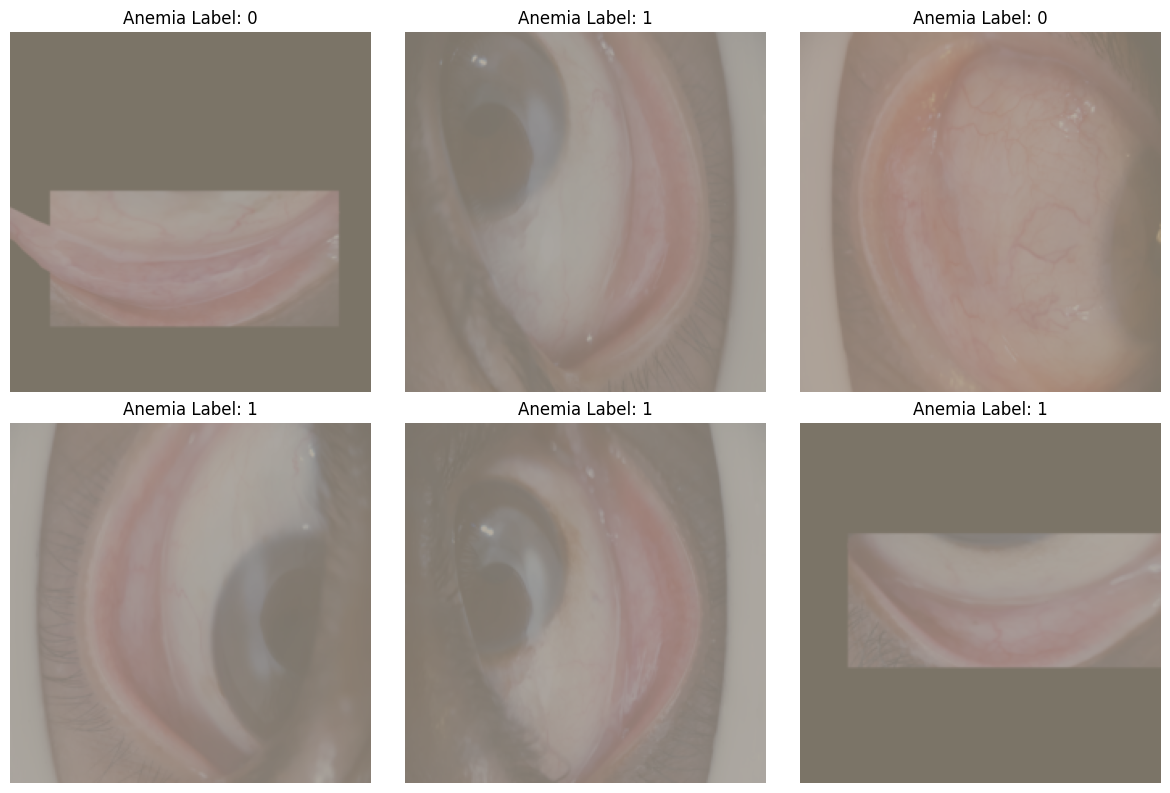


Train Class Distribution:
  Label 0: 55.12%
  Label 1: 44.88%

Validation Class Distribution:
  Label 0: 56.38%
  Label 1: 43.62%

Test Class Distribution:
  Label 0: 54.33%
  Label 1: 45.67%


In [8]:
import matplotlib.pyplot as plt
import torch
import os

# Visualize a few random samples from a Dataset
def visualize_samples(dataset, num_samples=6):
    plt.figure(figsize=(12, 8))
    for i in range(num_samples):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()  # C,H,W to H,W,C
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # Denormalize
        img = img.clip(0, 1)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Anemia Label: {label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example: visualize on training dataset
visualize_samples(train_dataset, num_samples=6)

# Check class distributions in train, val, test splits
def print_class_distribution(df, name):
    dist = df['anemia_label'].value_counts(normalize=True)
    print(f"\n{name} Class Distribution:")
    for label, prop in dist.items():
        print(f"  Label {label}: {prop*100:.2f}%")

print_class_distribution(train_df, 'Train')
print_class_distribution(val_df, 'Validation')
print_class_distribution(test_df, 'Test')

# Optional: Save preprocessed images as torch tensors to disk for faster loading
def save_preprocessed_tensors(dataset, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    for idx in range(len(dataset)):
        img, label = dataset[idx]
        filename = f"{idx}_label_{label}.pt"
        torch.save((img, label), os.path.join(save_dir, filename))

# Example save directory (can be Kaggle output or local)
# Uncomment to execute if desired
save_preprocessed_tensors(train_dataset, '/kaggle/working/preprocessed/train')
save_preprocessed_tensors(val_dataset, '/kaggle/working/preprocessed/val')
save_preprocessed_tensors(test_dataset, '/kaggle/working/preprocessed/test')

# Loading saved tensors back example
# img, label = torch.load('preprocessed/train/0_label_0.pt')

Batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
        0, 1, 0, 0, 0, 0, 1, 1])


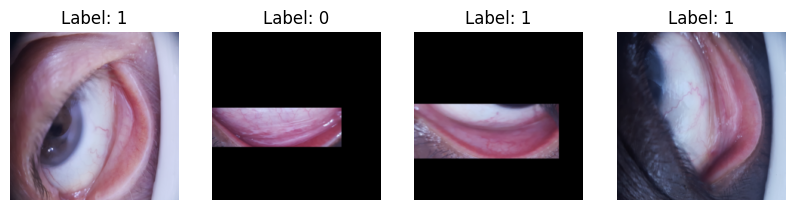

In [9]:
# Assuming you have 'train_dataset' or 'train_loader' ready:
import matplotlib.pyplot as plt
import numpy as np

# Show first few datapoints and labels
for images, labels in train_loader:
    print(f"Batch shape: {images.shape}")
    print(f"Labels: {labels}")

    # Display first 4 images
    fig, axes = plt.subplots(1, 4, figsize=(10, 3))
    for i in range(4):
        img = images[i].permute(1, 2, 0).numpy()  # Convert from (C,H,W) to (H,W,C)
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {labels[i].item()}")
        axes[i].axis("off")
    plt.show()
    break  # Stop after first batch

In [10]:
 device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = models.efficientnet_b0(pretrained=True)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)  # 2 classes: anemia vs non-anemia
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s]


In [11]:
def train_model(model, train_loader, val_loader, epochs=20, patience=5):
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs+1):
        # ---- Training ----
        model.train()
        train_loss, correct_train, total_train = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

        avg_train_loss = train_loss / total_train
        train_acc = correct_train / total_train

In [12]:
epochs = 20
best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(epochs):
    # ------------------------
    # Training
    # ------------------------
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    avg_train_loss = train_loss / total_train
    train_acc = correct_train / total_train

    # ------------------------
    # Validation
    # ------------------------
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    avg_val_loss = val_loss / total_val
    val_acc = correct_val / total_val

    # ------------------------
    # Print Results
    # ------------------------
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # ------------------------
    # Early Stopping + Save Best Model
    # ------------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⏹ Early stopping triggered.")
            break

Epoch 1/20 | Train Loss: 0.6472, Train Acc: 0.6122 | Val Loss: 0.6842, Val Acc: 0.6064
✅ Best model saved!
Epoch 2/20 | Train Loss: 0.5104, Train Acc: 0.7976 | Val Loss: 0.6108, Val Acc: 0.7340
✅ Best model saved!
Epoch 3/20 | Train Loss: 0.4212, Train Acc: 0.8293 | Val Loss: 0.4864, Val Acc: 0.7979
✅ Best model saved!
Epoch 4/20 | Train Loss: 0.3506, Train Acc: 0.8463 | Val Loss: 0.3971, Val Acc: 0.8191
✅ Best model saved!
Epoch 5/20 | Train Loss: 0.3030, Train Acc: 0.8902 | Val Loss: 0.3979, Val Acc: 0.7660
Epoch 6/20 | Train Loss: 0.2555, Train Acc: 0.9171 | Val Loss: 0.3668, Val Acc: 0.7872
✅ Best model saved!
Epoch 7/20 | Train Loss: 0.1954, Train Acc: 0.9341 | Val Loss: 0.3797, Val Acc: 0.8191
Epoch 8/20 | Train Loss: 0.1603, Train Acc: 0.9390 | Val Loss: 0.2947, Val Acc: 0.8936
✅ Best model saved!
Epoch 9/20 | Train Loss: 0.1484, Train Acc: 0.9537 | Val Loss: 0.3454, Val Acc: 0.8617
Epoch 10/20 | Train Loss: 0.1358, Train Acc: 0.9561 | Val Loss: 0.3391, Val Acc: 0.8511
Epoch 11/

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

In [14]:
def visualize_samples(dataset, class_names, num_samples=6):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]
        img = img / 2 + 0.5
        img = img.numpy().transpose((1,2,0))
        axes[i].imshow(img)
        axes[i].set_title(class_names[label])
        axes[i].axis("off")
    plt.show()


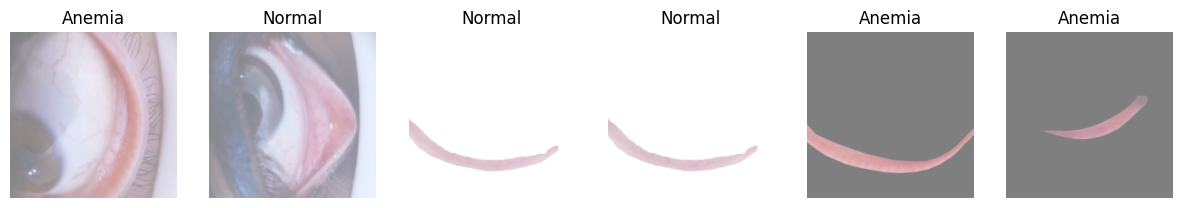

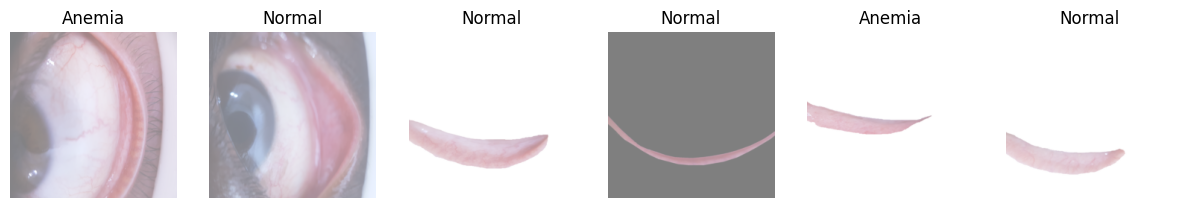

In [15]:
class_names = ["Anemia", "Normal"]
visualize_samples(val_dataset, class_names, num_samples=6)
visualize_samples(test_dataset, class_names, num_samples=6)


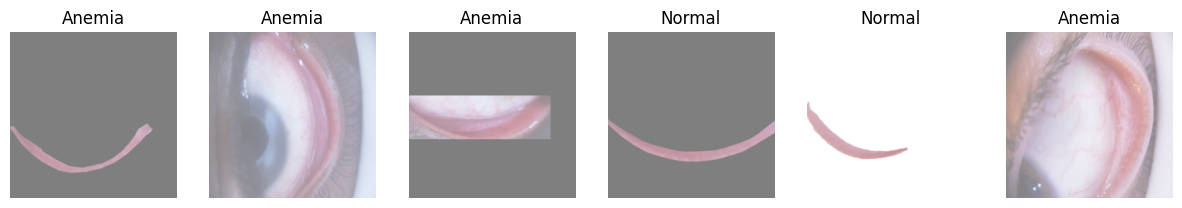

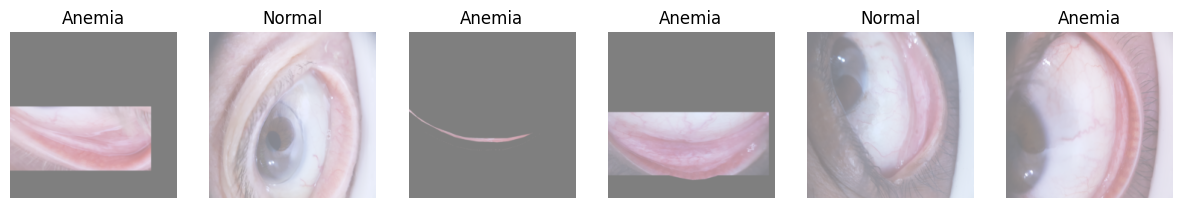

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Function to visualize random images
def visualize_samples(dataset, num_samples=6, class_names=None):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

    if hasattr(dataset, "classes"):
        class_names = dataset.classes
    elif class_names is None:
        class_names = ["Class 0", "Class 1"]

    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]

        img = img / 2 + 0.5
        img = img.numpy().transpose((1, 2, 0))

        axes[i].imshow(img)
        axes[i].set_title(class_names[label])
        axes[i].axis("off")

    plt.show()


custom_class_names = ["Anemia", "Normal"]

visualize_samples(val_dataset, num_samples=6, class_names=custom_class_names)
visualize_samples(test_dataset, num_samples=6, class_names=custom_class_names)


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# =======================
# Define Model
# =======================
class LightweightCNN(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(LightweightCNN, self).__init__()

        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, stride=2, padding=2)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# =======================
# Training Function
# =======================
def train_model(model, train_dataset, val_dataset, batch_size=32, epochs=20,
                learning_rate=1e-3, patience=5, device='cuda' if torch.cuda.is_available() else 'cpu'):

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # ============ Training ============
        model.train()
        train_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

        avg_train_loss = train_loss / total_train
        train_acc = correct_train / total_train

        # ============ Validation ============
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                correct_val += predicted.eq(labels).sum().item()

        avg_val_loss = val_loss / total_val
        val_acc = correct_val / total_val

        print(f"Epoch {epoch}/{epochs} - "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch} epochs.")
                break

    model.load_state_dict(torch.load("best_model.pth"))
    return model

# =======================
# Training Execution
# ======================
# train_dataset, val_dataset, test_dataset
model = LightweightCNN(input_channels=3, num_classes=2)
model = train_model(model, train_dataset, val_dataset, batch_size=32, epochs=20, learning_rate=1e-3)

# =======================
# Evaluation on Test set
# =======================
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
all_preds, all_labels = [], []

device = 'cuda' if torch.cuda.is_available() else 'cpu'

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds, digits=3))


Epoch 1/20 - Train Loss: 0.6860, Train Acc: 0.6317 - Val Loss: 0.6746, Val Acc: 0.5745
Epoch 2/20 - Train Loss: 0.5686, Train Acc: 0.7122 - Val Loss: 0.6525, Val Acc: 0.6809
Epoch 3/20 - Train Loss: 0.5599, Train Acc: 0.7220 - Val Loss: 0.6470, Val Acc: 0.7021
Epoch 4/20 - Train Loss: 0.5465, Train Acc: 0.6927 - Val Loss: 0.5626, Val Acc: 0.7234
Epoch 5/20 - Train Loss: 0.5178, Train Acc: 0.7463 - Val Loss: 0.5502, Val Acc: 0.7979
Epoch 6/20 - Train Loss: 0.5073, Train Acc: 0.7463 - Val Loss: 0.5460, Val Acc: 0.7766
Epoch 7/20 - Train Loss: 0.5097, Train Acc: 0.7463 - Val Loss: 0.5278, Val Acc: 0.7872
Epoch 8/20 - Train Loss: 0.5021, Train Acc: 0.7488 - Val Loss: 0.5092, Val Acc: 0.7766
Epoch 9/20 - Train Loss: 0.4973, Train Acc: 0.7707 - Val Loss: 0.5048, Val Acc: 0.7872
Epoch 10/20 - Train Loss: 0.4860, Train Acc: 0.7610 - Val Loss: 0.5104, Val Acc: 0.7766
Epoch 11/20 - Train Loss: 0.5212, Train Acc: 0.7244 - Val Loss: 0.5144, Val Acc: 0.7447
Epoch 12/20 - Train Loss: 0.4971, Train A

In [20]:
import pickle

# Save trained model as .pkl
with open("anemia_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved as anemia_model.pkl")


✅ Model saved as anemia_model.pkl


In [21]:
from google.colab import files
files.download("anemia_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>